# Healthcare Desert Analysis — Exploratory Notebook

Interactive exploration of census vulnerability variables, facility distributions,
isochrone coverage, and the final desert classification.
Run `main.py` at least once to populate `data/processed/` before working through these cells.

In [1]:
import sys
from pathlib import Path

# Add project root to path so src/ imports work from notebooks/
sys.path.insert(0, str(Path('..').resolve()))

from dotenv import load_dotenv
load_dotenv('../.env')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely.geometry import box

try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
print('Imports OK')

Imports OK


In [2]:
import config

print(f'State  : {config.STATE_NAME} ({config.STATE_FIPS})')
print(f'County : {config.COUNTY_FIPS}')
print(f'Year   : ACS {config.ACS_YEAR}')
print(f'Drive times (min): {config.DRIVE_TIMES_MINUTES}')
print(f'Vulnerability weights: {config.VULNERABILITY_WEIGHTS}')

State  : Nevada (32)
County : 003
Year   : ACS 2022
Drive times (min): [15, 30, 60]
Vulnerability weights: {'pct_elderly': 0.25, 'pct_uninsured': 0.3, 'pct_poverty': 0.25, 'pct_no_vehicle': 0.2}


## Study Area Bounds

Load the county tract geometries once and derive the bounding box used by all
subsequent maps.  This ensures every map centres on the county in `config.py`
regardless of county size.

In [3]:
from src.vulnerability_index import download_tiger_tracts

study_tracts = download_tiger_tracts(
    state_fips=config.STATE_FIPS,
    county_fips=config.COUNTY_FIPS,
)
print(f'Study area: {len(study_tracts):,} tracts ({config.STATE_NAME}, county {config.COUNTY_FIPS})')

# Projected bounds for matplotlib (metres)
_proj = study_tracts.to_crs(config.PROJECTED_CRS)
_b = _proj.total_bounds          # [minx, miny, maxx, maxy]
_pad_x = (_b[2] - _b[0]) * 0.05  # 5% padding
_pad_y = (_b[3] - _b[1]) * 0.05
MAP_XLIM = (_b[0] - _pad_x, _b[2] + _pad_x)
MAP_YLIM = (_b[1] - _pad_y, _b[3] + _pad_y)

# Geographic bbox for spatial filtering (degrees, with generous buffer)
_geo = study_tracts.total_bounds  # [minx, miny, maxx, maxy] in lon/lat
STUDY_BBOX = box(
    _geo[0] - 0.5, _geo[1] - 0.5,
    _geo[2] + 0.5, _geo[3] + 0.5,
)

print(f'Projected extent: x={MAP_XLIM}, y={MAP_YLIM}')

Study area: 535 tracts (Nevada, county 003)
Projected extent: x=(np.float64(-12911906.58229), np.float64(-12684868.63291)), y=(np.float64(4151403.744140001), np.float64(4431458.5006599985))


## 1. Census Data

In [4]:
from src.census_data import load_census_data

census = load_census_data(
    state_fips=config.STATE_FIPS,
    county_fips=config.COUNTY_FIPS,
)
print(f'{len(census):,} tracts loaded')
census.head(3)

535 tracts loaded


,B01003_001E,B17001_002E,B08201_002E,B08201_001E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,...,tract,GEOID,elderly_pop,pct_elderly,uninsured_pop,pct_uninsured,poverty_pop,pct_poverty,no_vehicle_hh,pct_no_vehicle
0,6833.0,597.0,41.0,1982.0,45.0,74.0,75.0,66.0,22.0,25.0,...,000101,32003000101,710.0,0.103908,1312.0,0.192009,597.0,0.087370,41.0,0.020686
1,6493.0,664.0,353.0,2043.0,45.0,41.0,78.0,47.0,28.0,0.0,...,000103,32003000103,677.0,0.104266,1866.0,0.287386,664.0,0.102264,353.0,0.172785
2,3916.0,475.0,52.0,1208.0,17.0,52.0,43.0,41.0,21.0,7.0,...,000105,32003000105,380.0,0.097038,633.0,0.161645,475.0,0.121297,52.0,0.043046


In [5]:
pct_cols = ['pct_elderly', 'pct_uninsured', 'pct_poverty', 'pct_no_vehicle']
census[pct_cols].describe().map(lambda x: f'{x:.3f}')

,pct_elderly,pct_uninsured,pct_poverty,pct_no_vehicle
count,535.000,535.000,535.000,535.000
mean,0.163,0.121,0.136,0.078
std,0.124,0.076,0.095,0.091
min,0.000,0.000,0.000,0.000
25%,0.097,0.063,0.063,0.017
50%,0.134,0.104,0.110,0.046
75%,0.185,0.172,0.189,0.107
max,0.889,0.493,0.565,0.633


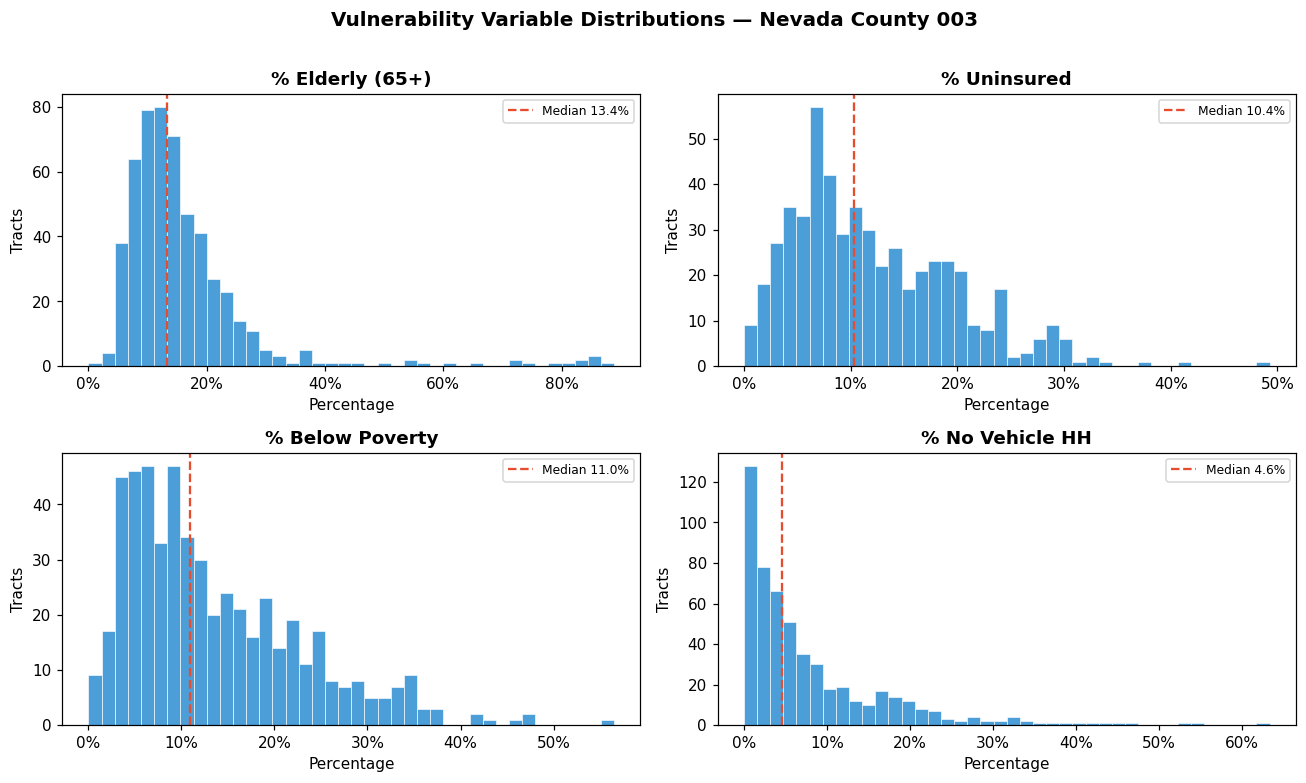

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
titles = {
    'pct_elderly':    '% Elderly (65+)',
    'pct_uninsured':  '% Uninsured',
    'pct_poverty':    '% Below Poverty',
    'pct_no_vehicle': '% No Vehicle HH',
}
for ax, (col, title) in zip(axes.flat, titles.items()):
    data = census[col].dropna() * 100
    ax.hist(data, bins=40, color='#4c9ed9', edgecolor='white', linewidth=0.4)
    ax.axvline(data.median(), color='#e64c2e', linewidth=1.5, linestyle='--',
               label=f'Median {data.median():.1f}%')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Percentage')
    ax.set_ylabel('Tracts')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=8)
fig.suptitle(
    f'Vulnerability Variable Distributions — {config.STATE_NAME} County {config.COUNTY_FIPS}',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

## 2. Healthcare Facilities (study area)

In [7]:
from src.facilities import load_facilities

facilities_all = load_facilities()
print(f'{len(facilities_all):,} total facilities (nationwide)')

# Clip to study area bounding box so the map stays focused on the county
facilities = facilities_all[facilities_all.within(STUDY_BBOX)].copy()
print(f'{len(facilities):,} facilities within study area bounding box')
facilities['type'].value_counts()

22,986 total facilities (nationwide)
85 facilities within study area bounding box


type
HRSA Health Center    60
Hospital              25
Name: count, dtype: int64

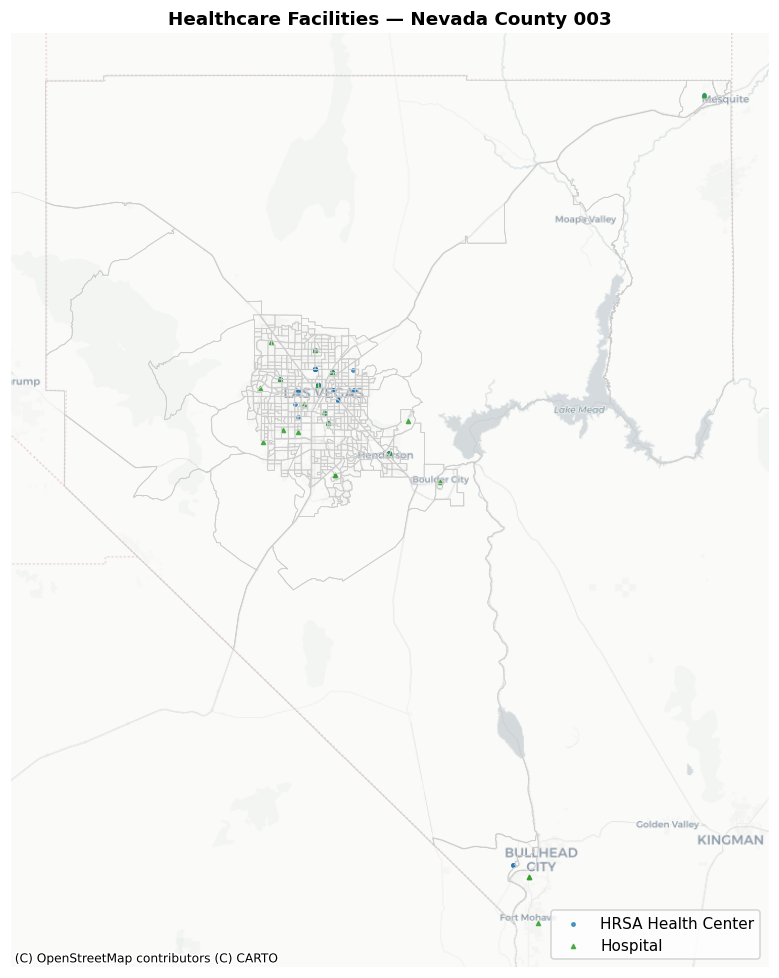

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
fac_proj = facilities.to_crs(config.PROJECTED_CRS)
hrsa = fac_proj[fac_proj['type'] == 'HRSA Health Center']
hosp = fac_proj[fac_proj['type'] == 'Hospital']

# Plot county outline as background
_proj.boundary.plot(ax=ax, color='#cccccc', linewidth=0.5)

if len(hrsa):
    hrsa.plot(ax=ax, color='#1f78b4', markersize=5, alpha=0.7, label='HRSA Health Center')
if len(hosp):
    hosp.plot(ax=ax, color='#33a02c', markersize=7, alpha=0.8, marker='^', label='Hospital')

if HAS_CTX:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_xlim(MAP_XLIM)
ax.set_ylim(MAP_YLIM)
ax.set_title(
    f'Healthcare Facilities — {config.STATE_NAME} County {config.COUNTY_FIPS}',
    fontweight='bold',
)
ax.legend(loc='lower right')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Isochrone Coverage (study area)

In [9]:
from src.isochrones import _load_isochrone_cache

isochrones = _load_isochrone_cache(
    config.DRIVE_TIMES_MINUTES,
    state_fips=config.STATE_FIPS,
    county_fips=config.COUNTY_FIPS,
)
if not isochrones:
    print('No cached isochrones — run main.py first (or with --skip-isochrones)')
else:
    study_proj_geom = _proj.geometry.unary_union
    for mins, gdf in sorted(isochrones.items()):
        clipped = gdf.to_crs(config.PROJECTED_CRS).clip(study_proj_geom)
        area_km2 = clipped.geometry.area.sum() / 1e6
        total_km2 = _proj.geometry.area.sum() / 1e6
        pct = area_km2 / total_km2 * 100 if total_km2 > 0 else 0
        print(f'{mins:3d}-min isochrone covers {area_km2:,.0f} km² ({pct:.1f}% of county area)')

 15-min isochrone covers 2,086 km² (6.5% of county area)
 30-min isochrone covers 3,427 km² (10.7% of county area)
 60-min isochrone covers 7,407 km² (23.0% of county area)


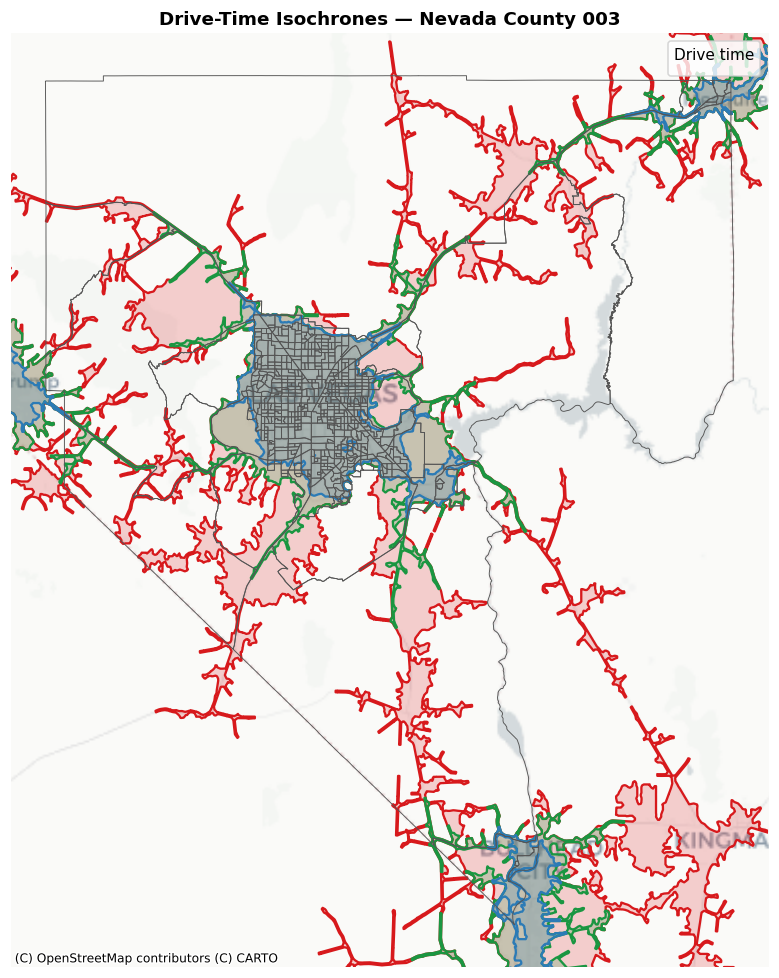

In [16]:
if isochrones:
    iso_colors = {15: '#2c7bb6', 30: '#1a9641', 60: '#d7191c'}
    fig, ax = plt.subplots(figsize=(11, 9))

    # Draw filled isochrones from largest to smallest
    for mins in sorted(isochrones, reverse=True):
        iso_proj = isochrones[mins].to_crs(config.PROJECTED_CRS)
        iso_proj.plot(ax=ax, color=iso_colors[mins], alpha=0.20, label=f'{mins} min')
        iso_proj.boundary.plot(ax=ax, color=iso_colors[mins], linewidth=1.5)

    # County outline
    _proj.boundary.plot(ax=ax, color='#555555', linewidth=0.6)

    if HAS_CTX:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Clip view to study area
    ax.set_xlim(MAP_XLIM)
    ax.set_ylim(MAP_YLIM)
    ax.set_title(
        f'Drive-Time Isochrones — {config.STATE_NAME} County {config.COUNTY_FIPS}',
        fontweight='bold',
    )
    ax.legend(title='Drive time', loc='upper right')
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(config.REPORTS_DIR / f'isochrones_{config.STATE_FIPS}_{config.COUNTY_FIPS}.png', dpi=150)
    plt.show()

## 4. Vulnerability Index & Desert Classification

In [11]:
# Filename includes state and county so switching config.py loads the right data
final_path = (
    config.PROCESSED_DIR
    / f'final_tracts_{config.STATE_FIPS}_{config.COUNTY_FIPS}.geojson'
)
if not final_path.exists():
    print(f'{final_path.name} not found — run main.py first')
else:
    tracts = gpd.read_file(final_path)
    print(f'{len(tracts):,} tracts loaded for {config.STATE_NAME} county {config.COUNTY_FIPS}')
    print(tracts['access_category'].value_counts())

535 tracts loaded for Nevada county 003
access_category
Adequate       530
Underserved      2
At Risk          2
Desert           1
Name: count, dtype: int64


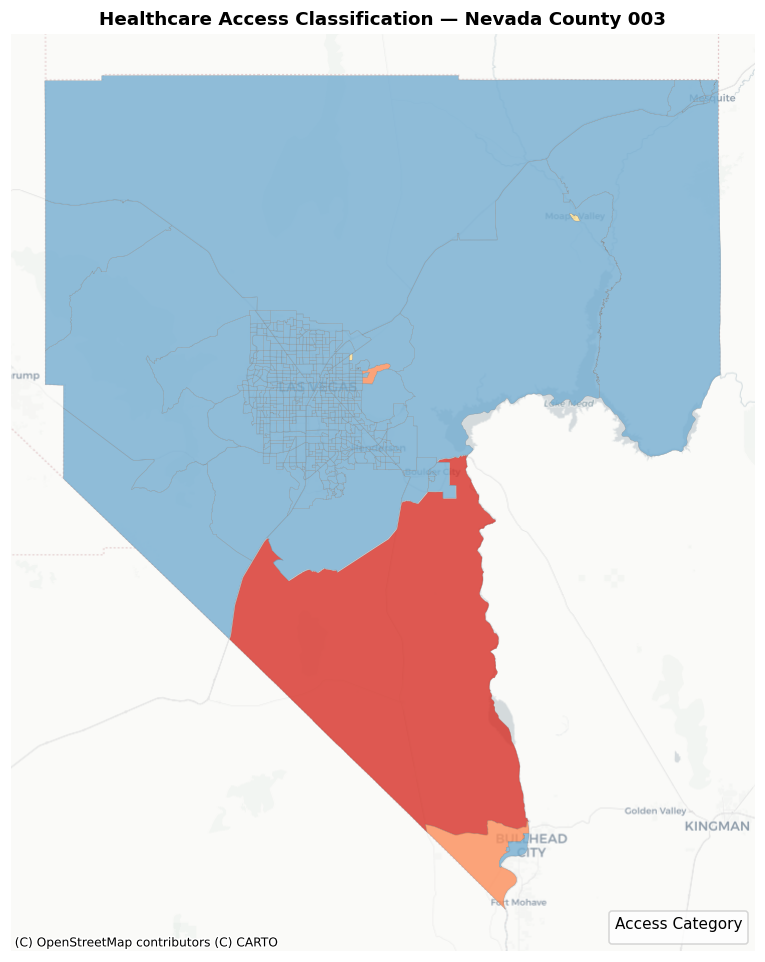

In [12]:
if 'tracts' in dir():
    ACCESS_COLORS = {
        'Desert': '#d73027',
        'At Risk': '#fc8d59',
        'Underserved': '#fee090',
        'Adequate': '#74add1',
    }
    tracts_proj = tracts.to_crs(config.PROJECTED_CRS)
    fig, ax = plt.subplots(figsize=(11, 9))
    for cat, color in ACCESS_COLORS.items():
        subset = tracts_proj[tracts_proj['access_category'] == cat]
        if len(subset):
            subset.plot(
                ax=ax, color=color, alpha=0.8, linewidth=0.2,
                edgecolor='#888', label=f'{cat} ({len(subset)})',
            )
    if HAS_CTX:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_xlim(MAP_XLIM)
    ax.set_ylim(MAP_YLIM)
    ax.legend(title='Access Category', loc='lower right', fontsize=9)
    ax.set_title(
        f'Healthcare Access Classification — {config.STATE_NAME} County {config.COUNTY_FIPS}',
        fontweight='bold',
    )
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

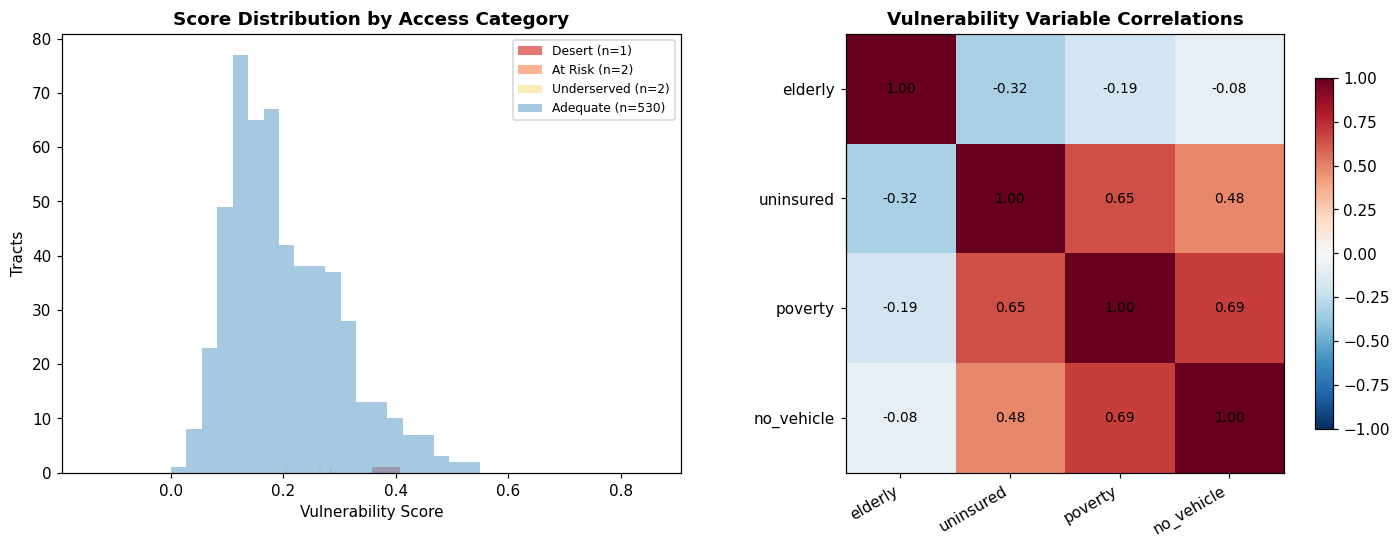

In [13]:
if 'tracts' in dir() and 'vulnerability_score' in tracts.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cats   = ['Desert', 'At Risk', 'Underserved', 'Adequate']
    colors = ['#d73027', '#fc8d59', '#fee090', '#74add1']
    for cat, col in zip(cats, colors):
        data = tracts.loc[tracts['access_category'] == cat, 'vulnerability_score'].dropna()
        if len(data):
            axes[0].hist(data, bins=20, alpha=0.65, color=col, label=f'{cat} (n={len(data)})')
    axes[0].set_xlabel('Vulnerability Score')
    axes[0].set_ylabel('Tracts')
    axes[0].set_title('Score Distribution by Access Category', fontweight='bold')
    axes[0].legend(fontsize=8)

    pct_cols = ['pct_elderly', 'pct_uninsured', 'pct_poverty', 'pct_no_vehicle']
    avail = [c for c in pct_cols if c in tracts.columns]
    if avail:
        corr = tracts[avail].corr()
        im = axes[1].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
        plt.colorbar(im, ax=axes[1], shrink=0.8)
        labels = [c.replace('pct_', '') for c in avail]
        axes[1].set_xticks(range(len(labels)))
        axes[1].set_yticks(range(len(labels)))
        axes[1].set_xticklabels(labels, rotation=30, ha='right')
        axes[1].set_yticklabels(labels)
        for i in range(len(avail)):
            for j in range(len(avail)):
                axes[1].text(j, i, f'{corr.iloc[i, j]:.2f}',
                             ha='center', va='center', fontsize=9)
        axes[1].set_title('Vulnerability Variable Correlations', fontweight='bold')

    plt.tight_layout()
    plt.show()

## 5. Summary Statistics

In [14]:
if 'tracts' in dir():
    from src.visualization import generate_summary_report
    summary = generate_summary_report(tracts)


  HEALTHCARE DESERT ANALYSIS — SUMMARY REPORT
  Nevada  |  ACS 2022

  Total tracts analysed : 535
  Population in deserts : 949

   Category  Tracts  % of Tracts  Mean Score  Population
   Adequate     530         99.1    0.203675   2254253.0
    At Risk       2          0.4    0.290533      7792.0
     Desert       1          0.2    0.357072       949.0
Underserved       2          0.4    0.235573      2932.0

  Top 10 Most Vulnerable Desert Tracts:
              NAME       GEOID  vulnerability_score  pct_elderly  pct_uninsured  pct_poverty  pct_no_vehicle
Census Tract 57.03 32003005703             0.357072       0.3804       0.119073     0.246575        0.216846




In [15]:
top10_path = config.REPORTS_DIR / 'top10_desert_tracts.csv'
if top10_path.exists():
    display(pd.read_csv(top10_path))
else:
    print('No top-10 report yet — run main.py first')

,NAME,GEOID,vulnerability_score,pct_elderly,pct_uninsured,pct_poverty,pct_no_vehicle
0,Census Tract 57.03,32003005703,0.357072,0.3804,0.119073,0.246575,0.216846
